In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path

file_name = "dataset/5-263902-A-36"
y, sr = librosa.load(file_name)

L = len(y)
t = np.arange(0,L) / sr

plt.plot(t,y)
plt.title('Audio waveform')
plt.xlabel('time(s)')
plt.ylabel('Amplitude')

plt.show()


In [ ]:
# FFT前のグラフ
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path

base_dir = Path('test')
for audio_dir in base_dir.glob('*.wav'):
    y, sr = librosa.load(audio_dir)

    L = len(y)
    t = np.arange(0,L) / sr
    
    

    plt.plot(t,y)
    plt.title('Audio waveform')
    plt.xlabel('time(s)')
    plt.ylabel('Amplitude')

    plt.show()


In [ ]:
# FFT後のグラフ
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
import math


base_dir = Path('test')
for audio_dir in base_dir.glob('*.wav'):
    y, sr = librosa.load(audio_dir)

    L = len(y)
    t = np.arange(0,L) / sr

    Y = np.fft.fft(y)
    P2 = np.abs(Y/L)
    half_L = L // 2
    P1 = P2[:half_L + 1]
    P1[1:-1] *= 2
    
    # 周波数軸の計算
    freqs = np.fft.fftfreq(L, 1/sr)
    freqs = freqs[:half_L + 1]
    
    plt.plot(freqs,P1)
    plt.title('Audio waveform')
    plt.xlabel('frequency')
    plt.ylabel('Amplitude')
    plt.xlim(0,5000)
    plt.show()
    


In [ ]:
# すべてを合体させる
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
import math


base_dir = Path('test')
for audio_dir in base_dir.glob('*.wav'):
    y, sr = librosa.load(audio_dir)

    L = len(y)
    t = np.arange(0,L) / sr

    Y = np.fft.fft(y)
    P2 = np.abs(Y/L)
    half_L = L // 2
    P1 = P2[:half_L + 1]
    P1[1:-1] *= 2
    
    # 周波数軸の計算
    freqs = np.fft.fftfreq(L, 1/sr)
    freqs = freqs[:half_L + 1]
    
    # FFT前のグラフ
    plt.subplot(2,1,1)
    plt.plot(t,y)
    plt.title('Audio waveform')
    plt.xlabel('time(s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    # FFT後のグラフ
    plt.subplot(2,1,2)
    plt.plot(freqs,P1)
    plt.title('Frequency Domain')
    plt.xlabel('frequency')
    plt.ylabel('Amplitude')
    plt.xlim(0,sr/2)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

In [ ]:
# STFT適用
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pathlib import Path
import math
from scipy.signal import stft 


base_dir = Path('test')
for audio_dir in base_dir.glob('*.wav'):
    y, sr = librosa.load(audio_dir)

    L = len(y)
    # t = np.arange(0,L) / sr

    f, t, spectrum = stft(y, fs=sr, nperseg=5000, boundary=None, padded=False)
    
    # dbに変換する
    db = 20 * np.log10(np.abs(spectrum) + 1e-10)
    
    # 色の範囲の計算
    max_db = np.max(db)
    min_db = max_db - 80
    plt.pcolormesh(t,f,db, shading='nearest', cmap='magma', vmin=min_db, vmax=max_db)
    plt.title('Frequency Domain')
    plt.xlabel('time(s)')
    plt.ylabel('frequency(Hz)')
    plt.colorbar(label='Amplitude(db)')
    plt.xlim(t[0], t[-1])
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    

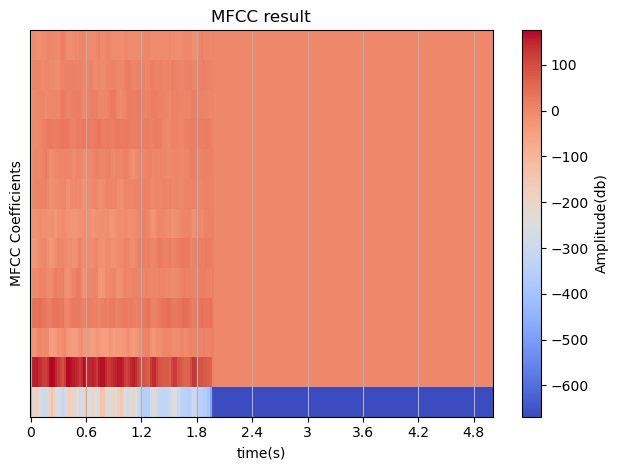

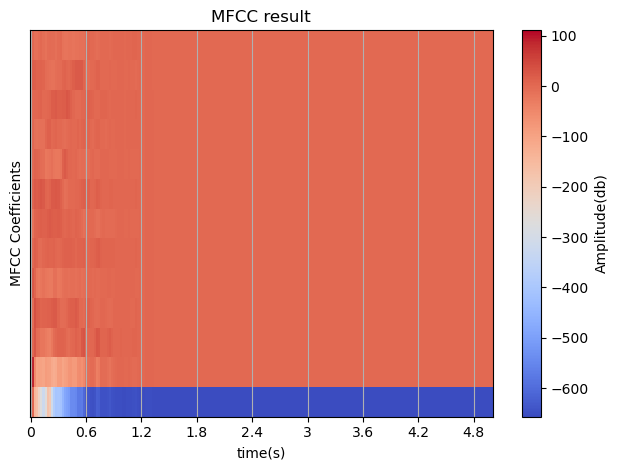

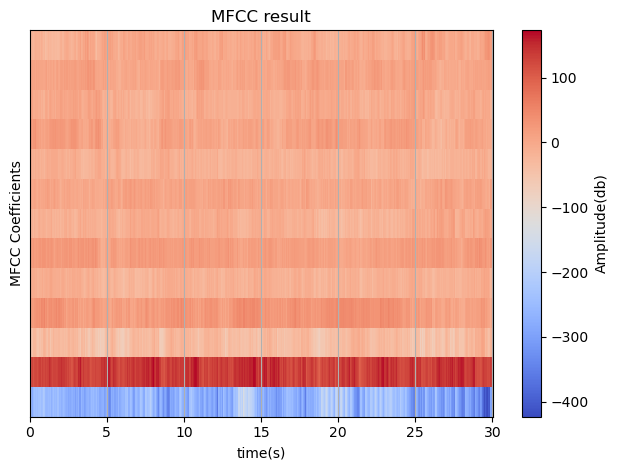

In [2]:
# MFCC適用
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path
import math
from scipy.signal import stft 

# 保存先のディレクトリ
save_dir = Path('testdata')
base_dir = Path('test')
for audio_dir in base_dir.glob('*.wav'):
    y, sr = librosa.load(audio_dir)

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.title('MFCC result')
    plt.xlabel('time(s)')
    plt.ylabel('MFCC Coefficients')
    plt.grid(True)
    plt.colorbar(label='Amplitude(db)')
    plt.tight_layout()
    plt.show()
    
    save_path = save_dir / f"{audio_dir.stem}_mfccs.npy"
    # 保存する
    np.save(save_path, mfccs)
    